¡Hola Ameua! Espero estés bien.

Mi nombre es **Gina Buvoli**. Un gusto conocerte, seré tu revisora en este proyecto.

A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:

Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.

Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más precisa, junto con algunos ejemplos prácticos. También estoy abierta a responder cualquier duda que tengas.

Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.

---

### Formato de Comentarios

<div class="alert alert-block alert-success">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
Esta parte está correctamente desarrollada.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>Atención ⚠️</b><br>
Hay una recomendación de mejora que no bloquea la aprobación.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>A resolver 🔴</b><br>
Hay un punto que debe corregirse antes de aprobar.
</div>

**¡Empecemos!** 🚀


<div class="alert alert-block alert-danger">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>

¡Hola Ameua!

El proyecto tiene una base sólida. La carga y exploración de los primeros datasets está bien realizada, identificas correctamente el top 10 de compañías y barrios, presentas análisis descriptivos claros y formulas adecuadamente H₀ y H₁.

Antes de aprobar, debes corregir dos puntos principales:

1. En la visualización de compañías calculas correctamente el top 10, pero el gráfico utiliza todo el DataFrame ordenado. El gráfico debe mostrar únicamente las diez compañías con más viajes.
2. La prueba estadística necesita completar la preparación y validación del tercer dataset: confirmar que los registros correspondan a sábados, identificar y tratar los viajes con <code>duration_seconds = 0</code> y aplicar Levene antes del t-test para decidir el valor de <code>equal_var</code>. No es suficiente asumir <code>equal_var=False</code> solo porque los tamaños de las muestras sean diferentes.

Después de realizar estos ajustes, vuelve a ejecutar las pruebas y actualiza las medias, valores p y conclusiones con los resultados definitivos.
</div>


<div class="alert alert-block alert-success">
<b>Review General. (Iteración 2)</b> <a class="tocSkip"></a>

¡Hola Ameua!

Corregiste correctamente los puntos pendientes de la primera revisión.

Ahora la visualización de compañías muestra únicamente el <b>top 10</b> solicitado. Además, completaste la preparación del dataset para la prueba estadística: confirmaste que los registros corresponden a sábados, identificaste y excluiste las seis duraciones iguales a cero y aplicaste la prueba de Levene antes del t-test para decidir correctamente el valor de <code>equal_var</code>.

También actualizaste las medias y la conclusión final con los resultados definitivos. La interpretación estadística es coherente: Levene obtiene un valor p aproximado de <code>0.6687</code>, por lo que se pueden asumir varianzas iguales, y el t-test obtiene aproximadamente <code>1.33e-11</code>, por lo que se rechaza H₀.

El proyecto queda aprobado. Buen trabajo incorporando las observaciones de la primera iteración y fortaleciendo la metodología del análisis.

Saludos,<br>
<b>Gina Buvoli</b>
</div>


# **1. Importar las librerías**

En primer lugar, importamos las librerías necesarias para trabajar con los datos. Utilizaremos pandas para cargar, explorar y manipular los archivos CSV. También utilizaremos matplotlib y plotly.graph_objects posteriormente para realizar visualizaciones.

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1) — Sección 1</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
Las librerías necesarias están importadas correctamente al inicio del proyecto. La organización es clara y adecuada para el análisis que desarrollas posteriormente.
</div>


# **2. Cargar los archivos CSV**

A continuación, cargamos los dos archivos CSV proporcionados para el análisis.

El primer archivo contiene la cantidad de viajes realizados por cada compañía de taxis durante los días 15 y 16 de noviembre de 2017.

El segundo archivo contiene los barrios de Chicago donde finalizaron los viajes y el promedio de viajes que terminaron en cada barrio durante noviembre de 2017.

In [50]:
company_trips = pd.read_csv('/datasets/project_sql_result_01.csv')

dropoff_trips = pd.read_csv('/datasets/project_sql_result_04.csv')

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1) — Sección 2</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
Los dos archivos del análisis exploratorio se cargan correctamente y utilizas nombres de variables descriptivos que permiten distinguir fácilmente el contenido de cada DataFrame.
</div>


# **3. Primer vistazo al dataset de compañías y  finalización de Viajes**

Comenzaremos estudiando el primer DataFrame. Mostraremos las primeras filas para conocer la estructura de los datos y verificar que las columnas se hayan cargado correctamente.

In [51]:
company_trips.head() #Primeros 5 datos de compañias de Taxis

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [52]:
company_trips.info() #Info del dataframe  de compañias de Taxis
company_trips.shape #Filas y columnas  de compañias de Taxis


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


(64, 2)

In [53]:
dropoff_trips.head()  #Primeros 5 datos finalizacion de viajes en Chicago

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [54]:
dropoff_trips.info() #Info del dataframe datos finalizacion de viajes en Chicago
dropoff_trips.shape #Filas y columnas datos finalizacion de viajes en Chicago

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


(94, 2)

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1) — Sección 3</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
Realizas una exploración inicial adecuada con <code>head()</code>, <code>info()</code> y <code>shape</code>. Esto permite comprobar estructura, número de registros y tipos de datos antes de continuar el análisis.
</div>


# **4.Revisar valores ausentes y duplicados**

Verificaremos si existen valores ausentes en alguna de las columnas. Los valores faltantes pueden afectar posteriormente los cálculos estadísticos y las visualizaciones.

In [55]:
#Valores ausentes o duplicados en dataframe de compañias de taxis

print(company_trips.isna().sum())
print(company_trips.duplicated().sum())


company_name    0
trips_amount    0
dtype: int64
0


In [56]:
#Valores ausentes o duplicados en dataframe finalizacion de viajes en chicago
print(dropoff_trips.isna().sum())
print(dropoff_trips.duplicated().sum())

dropoff_location_name    0
average_trips            0
dtype: int64
0


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1) — Sección 4</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
La revisión de calidad está correctamente documentada: compruebas valores ausentes y duplicados en ambos DataFrames y confirmas que no existen registros problemáticos en esta etapa.
</div>


# **5. Estadísticas descriptivas**

Para la columna trips_amount, calcularemos estadísticas descriptivas que nos permitan conocer el comportamiento general de la cantidad de viajes realizados por las diferentes compañías.

*Podemos observar:*
cantidad de registros
promedio
desviación estándar
mínimo
percentiles
máximo

Esto nos ayudará posteriormente a identificar compañías con una cantidad de viajes significativamente mayor o menor que las demás.

In [57]:
company_trips.describe() # estadísticas para dataframe de Compañias de Taxis

,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


Utilizamos estadísticas descriptivas para conocer la distribución del promedio de viajes que finalizan en los diferentes barrios. El objetivo es identificar valores mínimos, máximos y tendencias generales.

In [58]:
dropoff_trips.describe()  # estadísticas para dataframe de viajes finalziados

,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


# *Analisis descriptivo de los datos estadísticos de las compañias de taxi*

La variable trips_amount presenta una gran dispersión. La cantidad promedio de viajes es de 2,145.48, pero la mediana es solamente 178.5 viajes.

Esta diferencia es muy importante:

Media = 2,145.48 vs. Mediana = 178.50

Esto indica que unas pocas compañías tienen una cantidad de viajes muy superior al resto, elevando considerablemente el promedio.

La desviación estándar de 3,812.31 también es considerablemente superior a la media, lo que confirma que existe una alta variabilidad entre las compañías.

El rango también es muy amplio:

Mínimo: 2 viajes
Máximo: 19,558 viajes

Además, el 50% de las compañías se encuentra entre 20.75 y 2,106.50 viajes aproximadamente.

Conclusión para trips_amount

La cantidad de viajes por compañía presenta una distribución altamente dispersa y probablemente sesgada hacia la derecha. La diferencia considerable entre la media y la mediana indica que unas pocas compañías concentran una cantidad muy elevada de viajes, mientras que la mayoría registra cantidades significativamente menores. Por esta razón, la mediana resulta más representativa del comportamiento típico de una compañía que la media.


# *Analisis descriptivo de los datos estadísticos de los viajes finalizados*
Aquí encontramos un comportamiento todavía más marcado.

El promedio de viajes por barrio es de aproximadamente 599.95, mientras que la mediana es solamente 52.02.

Tenemos entonces:

Media = 599.95 vs. Mediana = 52.02

Esto significa que algunos barrios tienen un promedio de viajes extraordinariamente alto y están elevando significativamente la media general.

La desviación estándar es de 1,714.59, casi tres veces la media, lo que evidencia una enorme variabilidad entre los barrios.

El rango también es extremadamente amplio:

Mínimo: 1.8 viajes
Máximo: 10,727.47 viajes

Además, el 75% de los barrios tiene un promedio de 298.86 viajes o menos, mientras que solamente el 25% superior supera ese valor.

Conclusión para average_trips

La variable average_trips presenta una elevada dispersión y una distribución fuertemente sesgada hacia valores altos. La diferencia entre la media de 599.95 y la mediana de 52.02 demuestra que unos pocos barrios concentran una cantidad considerablemente mayor de viajes. Por lo tanto, la mediana representa mejor el comportamiento típico de los barrios que la media.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1) — Sección 5</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
Las estadísticas descriptivas están bien interpretadas. Comparas media y mediana, observas la dispersión y explicas correctamente que unas pocas compañías y barrios concentran valores considerablemente mayores que el resto.
</div>


# **6. Ordenamiento / identificación de patrones**

# *Ordenar las compañías por cantidad de viajes*

Ordenaremos las compañías de taxis de acuerdo con la cantidad de viajes realizados, de mayor a menor. Esto permite identificar rápidamente cuáles fueron las empresas con mayor volumen de viajes durante el período analizado.

In [59]:
company_trips_sorted = company_trips.sort_values(
    by='trips_amount',
    ascending=False
)

company_trips_sorted.head(10)

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


# *Identificar los barrios con mayor promedio de viajes*

Ordenamos los barrios de acuerdo con su promedio de viajes, de mayor a menor. De esta manera podemos identificar cuáles son los destinos con mayor concentración de viajes durante noviembre de 2017.

In [60]:
dropoff_trips_sorted = dropoff_trips.sort_values(
    by='average_trips',
    ascending=False
)

dropoff_trips_sorted.head(10)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1) — Sección 6</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
Ordenas correctamente los datos e identificas las diez compañías con más viajes y los diez barrios con mayor promedio de viajes finalizados. Esta preparación cumple con lo solicitado y deja listos los subconjuntos para las visualizaciones.
</div>


# **7. Comprobación de los tipos de datos**

Verificamos los tipos de datos de ambos DataFrames para asegurarnos de que las variables numéricas estén correctamente identificadas como valores numéricos y que las variables categóricas correspondan a cadenas de texto.

In [61]:
print(company_trips.dtypes)
print()
print(dropoff_trips.dtypes)

company_name    object
trips_amount     int64
dtype: object

dropoff_location_name     object
average_trips            float64
dtype: object


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1) — Sección 7</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
Los tipos de datos son adecuados para las variables disponibles: las categorías permanecen como texto y las métricas de viajes son numéricas. La comprobación está correctamente realizada.
</div>


# **8. Visualizaciones gráficas**

Para facilitar la comparación entre las compañías, construiremos un gráfico de barras. Cada barra representa una compañía y su altura corresponde a la cantidad de viajes realizados.

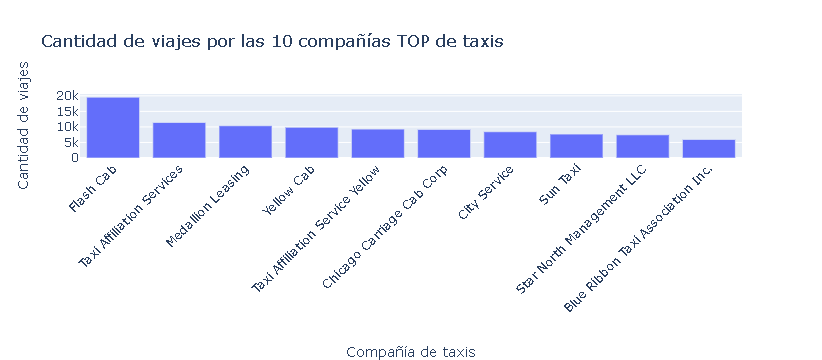

In [62]:
#Visualización de Gráfico de comparativa entre compañías de taxis con barra
fig = go.Figure(
    data=[
        go.Bar(
            x=company_trips_sorted['company_name'].head(10),
            y=company_trips_sorted['trips_amount']
        )
    ]
)

fig.update_layout(
    title='Cantidad de viajes por las 10 compañías TOP de taxis',
    xaxis_title='Compañía de taxis',
    yaxis_title='Cantidad de viajes',
    xaxis_tickangle=-45
)

fig.show()

El gráfico permite comparar visualmente el volumen de viajes entre el top 10 de las diferentes compañías. Se puede observar cuáles empresas concentran una mayor cantidad de viajes y cuáles presentan una participación menor.

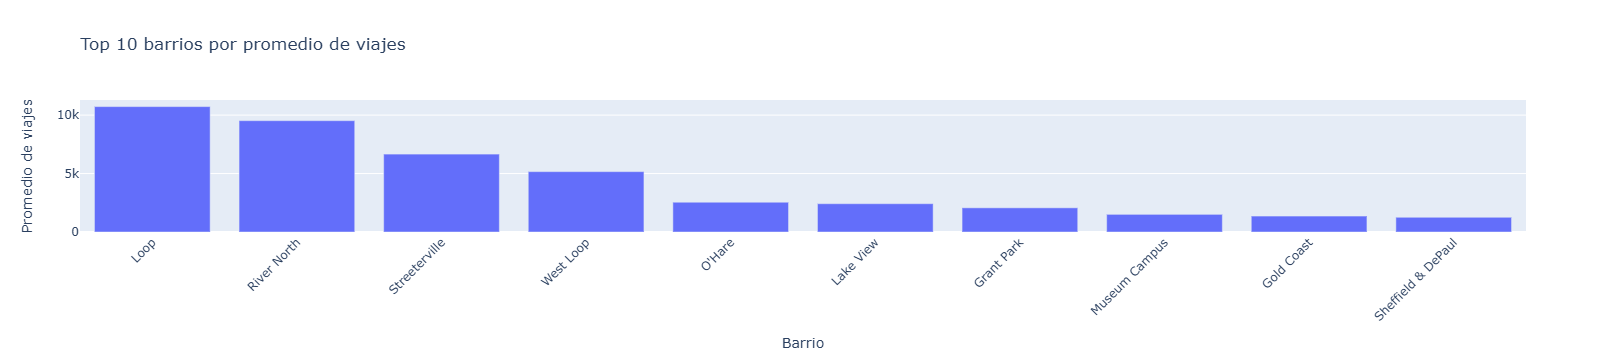

In [63]:
#Visualización gráfica de los barrios de finalización de viajes

fig = go.Figure(
    data=[
        go.Bar(
            x=dropoff_trips_sorted['dropoff_location_name'].head(10),
            y=dropoff_trips_sorted['average_trips'].head(10)
        )
    ]
)

fig.update_layout(
    title='Top 10 barrios por promedio de viajes',
    xaxis_title='Barrio',
    yaxis_title='Promedio de viajes',
    xaxis_tickangle=-45
)

fig.show()

La visualización permite identificar los barrios que concentran el mayor promedio de viajes. Los primeros lugares representan las zonas que reciben una mayor cantidad de viajes como destino.

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora. (Iteración 1) — Sección 8</b> <a class="tocSkip"></a><br>
<b>A resolver 🔴</b><br>
El gráfico de barrios sí muestra correctamente el top 10. Sin embargo, en el gráfico de compañías utilizas <code>company_trips_sorted</code> completo, por lo que se visualizan todas las compañías. El proyecto solicita comparar las <b>diez compañías con más viajes</b>. Usa el subconjunto top 10 que ya calculaste y ajusta el gráfico para que la visualización coincida con ese análisis.
</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 2) — Sección 8</b> <a class="tocSkip"></a><br>
<b>Corregido ✅</b><br>
Ahora la visualización utiliza correctamente únicamente las diez compañías con mayor número de viajes. El gráfico, su título y la interpretación coinciden con el top 10 solicitado.
</div>


# **9. Conclusiones preliminares e interpretaciones**

El análisis exploratorio de los datos muestra que los viajes en taxi en Chicago presentan una distribución altamente desigual tanto entre las compañías de taxis como entre los barrios de destino. En el caso de las compañías, Flash Cab y Taxi Affiliation Services destacan por registrar un volumen de viajes considerablemente superior al de muchas de las demás empresas.

Esta concentración también se observa en los barrios. Loop, River North, Streeterville y West Loop presentan los mayores promedios de viajes, destacándose especialmente Loop y River North. Esto indica que determinadas zonas de la ciudad concentran una demanda de transporte significativamente mayor.

Los resultados estadísticos respaldan visualmente estas observaciones. La diferencia entre la media y la mediana en trips_amount (2,145.48 frente a 178.50) y en average_trips (599.95 frente a 52.02), junto con las elevadas desviaciones estándar, evidencia una distribución sesgada hacia la derecha y la presencia de valores extremos.

En consecuencia, la media debe interpretarse con precaución, ya que está influenciada por las compañías y barrios con volúmenes excepcionalmente altos. La mediana proporciona una mejor aproximación al comportamiento típico de una compañía o barrio.

Como conclusión, los datos sugieren una fuerte concentración de la demanda de taxis en determinadas empresas y zonas geográficas de Chicago. No obstante, estas observaciones son exploratorias y deberán complementarse con análisis estadísticos adicionales para determinar si las diferencias observadas son significativas y para estudiar la relación entre las condiciones meteorológicas y la duración de los viajes.

Concentración geográfica de la demanda

El gráfico de barrios permite identificar una concentración especialmente fuerte en determinadas zonas.
Loop sobresale como el principal destino de los viajes, seguido por River North, Streeterville y West Loop.
Esto sugiere preliminarmente que determinadas zonas concentran una demanda de transporte significativamente mayor que otras.

Concentración empresarial

El gráfico de compañías muestra un comportamiento similar al observado en los barrios: pocas compañías concentran una gran cantidad de viajes, mientras que muchas empresas tienen volúmenes considerablemente menores.
Esto puede observarse claramente en la caída que presenta el gráfico después de las compañías líderes.
Por tanto, preliminarmente podemos plantear que: El mercado de taxis analizado presenta una distribución desigual de los viajes tanto desde el punto de vista de las compañías como de los destinos.
las primeras 3 del top 10 de las empresas concentra una parte importante de los viajes, mientras que un pequeño grupo de barrios concentra una parte importante de los destinos.



<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1) — Sección 9</b> <a class="tocSkip"></a><br>
<b>Atención ⚠️</b><br>
Las conclusiones preliminares son claras y utilizan evidencia numérica para interpretar la concentración de viajes. Después de corregir el gráfico de compañías, revisa que cualquier interpretación asociada a esa visualización se refiera específicamente al top 10 solicitado.
</div>


# **10. Prueba de hipótesis**

Debemos comprobar estadísticamente si la duración promedio de los viajes Loop → O'Hare cambia cuando el sábado presenta condiciones meteorológicas adversas (Bad) frente a condiciones normales (Good).

La afirmación que debemos probar es:

"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".

Por lo tanto, planteamos una prueba bilateral, porque queremos determinar si la duración cambia, sin especificar previamente si aumenta o disminuye.

Hipótesis nula — H₀

H₀: La duración promedio de los viajes en sábados lluviosos es igual a la duración promedio en sábados con buenas condiciones climáticas.

Matemáticamente:

μ₍Bad₎ = μ₍Good₎

Hipótesis alternativa — H₁

H₁: La duración promedio de los viajes en sábados lluviosos es diferente de la duración promedio en sábados con buenas condiciones climáticas.

Matemáticamente:

μ₍Bad₎ ≠ μ₍Good₎

Es importante utilizar una hipótesis alternativa bilateral, queremos validar solo si la duración cambia, no un aumento o disminución especificamente.

Utilizaría: alpha = 0.05

Es decir, un nivel de significación del 5% de rechazar la hipótesis nula cuando realmente sea verdadera.

# *1. Importación y exploración de los datos*


In [64]:
from scipy import stats

#Cargar los datos
trips = pd.read_csv('/datasets/project_sql_result_07.csv')

# Convertir start_ts a datetime
trips['start_ts'] = pd.to_datetime(trips['start_ts'])

print ('# Revisar los datos')
print(trips.head())
print(trips.info())

print ('#Validar valores nulos, duplicados')
print(trips.isna().sum())
print(trips.duplicated().sum())

print ('# Revisar las condiciones climáticas')
print(trips['weather_conditions'].value_counts())

# Revisar los datos
             start_ts weather_conditions  duration_seconds
0 2017-11-25 16:00:00               Good            2410.0
1 2017-11-25 14:00:00               Good            1920.0
2 2017-11-25 12:00:00               Good            1543.0
3 2017-11-04 10:00:00               Good            2512.0
4 2017-11-11 07:00:00               Good            1440.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB
None
#Validar valores nulos, duplicados
start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64
197
# Revisar las condiciones climáticas
Go

# *Confirmar que los registros corresponden a sábados*
Con el fin de corroborar que los registros de la base corresponden exclusivamente al dia sábado

In [65]:
trips['day_of_week'] = trips['start_ts'].dt.day_name()

print(trips['day_of_week'].value_counts())

#También podemos comprobar específicamente si todos son sábado:

print(trips['day_of_week'].unique())

#una validación directa:

print('¿Todos los viajes son sábado?:',
      (trips['day_of_week'] == 'Saturday').all())

Saturday    1068
Name: day_of_week, dtype: int64
['Saturday']
¿Todos los viajes son sábado?: True


Se verificó explícitamente el día de la semana utilizando la columna start_ts. Los registros del conjunto de datos corresponden a viajes realizados los sábados, por lo que el dataset es consistente con la hipótesis planteada.

# *Revisar las duraciones iguales a cero*
Una duración de 0 segundos no representa un viaje válido y puede distorsionar el cálculo de las medias y la prueba de hipótesis.

In [66]:
#Ahora debemos identificar los viajes cuya duración es 0.

zero_duration = trips[trips['duration_seconds'] == 0]

print('Cantidad de viajes con duración 0:',
      len(zero_duration))

#También podemos saber en qué condición climática aparecen:

print(
    zero_duration['weather_conditions'].value_counts()
)

Cantidad de viajes con duración 0: 6
Good    6
Name: weather_conditions, dtype: int64


In [67]:
#Los eliminamos

trips_clean = trips[
    trips['duration_seconds'] > 0
].copy()

#Comprobamos:

print(
    'Registros antes:',
    len(trips)
)

print(
    'Registros después:',
    len(trips_clean)
)

print(
    'Duraciones cero restantes:',
    (trips_clean['duration_seconds'] == 0).sum()
)

Registros antes: 1068
Registros después: 1062
Duraciones cero restantes: 0


# *2.Separar los grupos*

Una vez validamos que los datos cumplen con los requisitos para ser analizados, para la prueba necesitamos comparar dos grupos:

Good: sábados sin lluvia/tormenta con duración mayor a 0 segundos.
Bad: sábados con lluvia/tormenta con duración mayor a 0 segundos.

In [71]:

# Filtrar viajes con buen clima y duración mayor que 0
good = trips[
    (trips['weather_conditions'] == 'Good') &
    (trips['duration_seconds'] > 0)
]['duration_seconds']

# Filtrar viajes con mal clima y duración mayor que 0
bad = trips[
    (trips['weather_conditions'] == 'Bad') &
    (trips['duration_seconds'] > 0)
]['duration_seconds']

#Resultados estadisticos por grupos

print('Good:')
print(good.describe())

print('\nBad:')
print(bad.describe())

Good:
count     882.000000
mean     2013.278912
std       743.565217
min        60.000000
25%      1397.250000
50%      1800.000000
75%      2460.000000
max      7440.000000
Name: duration_seconds, dtype: float64

Bad:
count     180.000000
mean     2427.205556
std       721.314138
min       480.000000
25%      1962.000000
50%      2540.000000
75%      2928.000000
max      4980.000000
Name: duration_seconds, dtype: float64


In [76]:
#mostrar las medias en minutos:
print('Media Good:',good.mean()/60,'minutos')

print('Media Bad:',bad.mean()/60,'minutos')

print('Diferencia:', (bad.mean() - good.mean())/60,'minutos')

Media Good: 33.554648526077095 minutos
Media Bad: 40.45342592592593 minutos
Diferencia: 6.898777399848833 minutos


Por lo tanto, descriptivamente, en estos datos los viajes durante condiciones meteorológicas adversas son, en promedio, aproximadamente (6.89 minutos) más largos.

# *3. Planteamiento de las hipótesis*

Para comprobar la hipótesis, no debemos decidir equal_var simplemente porque tenemos 888 observaciones contra 180. Primero debemos comprobar estadísticamente si las varianzas son iguales, a través de la Prueba de levene.

La hipótesis de Levene es:

H₀ de Levene

Las varianzas de los dos grupos son iguales.

H₁ de Levene

Las varianzas de los dos grupos son diferentes.



In [84]:
levene_result = stats.levene(
    good,
    bad
)

print('Estadístico de Levene:',
      levene_result.statistic)

print('p-value de Levene:',
      levene_result.pvalue)

alpha = 0.05

if levene_result.pvalue < alpha:
    print('Las varianzas son significativamente diferentes.')
    equal_var = False
else:
    print('No hay evidencia suficiente para afirmar que las varianzas sean diferentes.')
    equal_var = True

Estadístico de Levene: 0.18319196347283054
p-value de Levene: 0.6687312920630069
No hay evidencia suficiente para afirmar que las varianzas sean diferentes.


# *Prueba Estadística*

H₀ (hipótesis nula):

La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es la misma en los sábados con buenas condiciones climáticas y en los sábados con malas condiciones climáticas.

En términos estadísticos:

H₀: μGood = μBad

H₁ (hipótesis alternativa):

La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es diferente entre los sábados con buenas condiciones climáticas y los sábados con malas condiciones climáticas.

H₁: μGood ≠ μBad

Es importante que sea una prueba bilateral, porque la hipótesis dice que la duración "cambia", pero no especifica que necesariamente aumente o disminuya.

Tenemos:

Una variable numérica: duration_seconds.

Dos grupos independientes: Good y Bad.

Queremos comparar sus medias.

No conocemos la media poblacional.

Los tamaños de los grupos son diferentes: 888 vs. 180.

Estadisticamente no hay evidencia para afirmar que las varianzas sean diferentes, por lo tanto equal_var = true

Por estas características, utilizaremos una prueba t para dos muestras independientes con las dos poblaciones tienen exactamente la misma varianza.

In [85]:
alpha = 0.05

results = stats.ttest_ind(
    good,
    bad,
    equal_var=True
)

print('Estadístico t:', results.statistic)
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula.')
else:
    print('No rechazamos la hipótesis nula.')

Estadístico t: -6.8404589322166425
p-value: 1.3318772977743245e-11
Rechazamos la hipótesis nula.


El p-value extremadamente pequeño (1.33 × 10⁻¹¹) indica que, suponiendo que la duración promedio de los viajes fuera realmente igual entre ambos tipos de clima, sería extremadamente improbable observar una diferencia como la encontrada.

Por lo tanto:

Existe evidencia estadísticamente significativa de que la duración promedio de los viajes desde el Loop hasta O'Hare cambia entre los sábados con buenas y malas condiciones climáticas.

El estadístico t negativo (-6.84) indica que, según el orden en que introdujiste las muestras en ttest_ind(good, bad), la media del grupo Good es menor que la del grupo Bad.

Es decir, los datos apuntan a que:

Los viajes realizados bajo condiciones climáticas adversas (Bad) tienen una duración promedio mayor que los realizados bajo condiciones favorables (Good).

# *4. Conclusión de prueba de hipotesis*

Se estableció un nivel de significación de α = 0.05. Primero se realizó la prueba de Levene, cuyo p-value fue 0.6687, superior a 0.05, por lo que no se encontró evidencia suficiente para considerar diferentes las varianzas de los grupos. En consecuencia, se utilizó una prueba t de Student para muestras independientes asumiendo varianzas iguales (equal_var=True).

La prueba t produjo un estadístico de -6.8405 y un p-value de 1.33 × 10⁻¹¹, significativamente inferior a 0.05. Por tanto, se rechaza la hipótesis nula y se concluye que existe una diferencia estadísticamente significativa en la duración promedio de los viajes desde el Loop hasta O'Hare entre los sábados con buenas y malas condiciones climáticas.

El signo negativo del estadístico t, considerando el orden Good - Bad, indica que la duración promedio del grupo Good es menor que la del grupo Bad. Por lo tanto, los resultados sugieren que las condiciones climáticas adversas están asociadas con viajes de mayor duración.

Además, los datos muestran que los viajes bajo condiciones Bad tienen una duración promedio superior en 6,89 minutos aproximadante a los de Good conditions.

### *Nota importante: esto demuestra una diferencia estadísticamente significativa en estos datos, pero no necesariamente demuestra que la lluvia sea la única causa del aumento de duración; otros factores podrían influir en el tiempo de viaje.*

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora. (Iteración 1) — Sección 10</b> <a class="tocSkip"></a><br>
<b>A resolver 🔴</b><br>
La formulación de H₀ y H₁ es correcta y la comparación entre los grupos <code>Good</code> y <code>Bad</code> está bien planteada. Antes de aprobar esta sección debes completar tres validaciones importantes:

<ul>
<li><b>Confirma que los registros correspondan a sábados.</b> Ya convertiste <code>start_ts</code> a fecha; utiliza esa información para verificar explícitamente el día de la semana.</li>
<li><b>Revisa las duraciones iguales a cero.</b> En la salida de <code>describe()</code> se observa un mínimo de <code>0</code> segundos en el grupo Good. Identifica cuántos registros tienen <code>duration_seconds = 0</code> y trátalos antes de formar las muestras, porque una duración de cero no representa un viaje válido y puede afectar las medias y las pruebas.</li>
<li><b>No asumas varianzas diferentes por el tamaño de las muestras.</b> Tener 888 observaciones frente a 180 no determina si las varianzas son iguales. Aplica primero la prueba de Levene, interpreta su valor p y utiliza ese resultado para elegir <code>equal_var=True</code> o <code>False</code> en <code>ttest_ind()</code>.</li>
</ul>

Después de estas correcciones, vuelve a ejecutar el análisis y actualiza las medias, el valor p y la conclusión final con los resultados definitivos.
</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 2) — Sección 10</b> <a class="tocSkip"></a><br>
<b>Corregido ✅</b><br>
Completaste correctamente las validaciones solicitadas: confirmas que todos los registros corresponden a sábados, identificas y excluyes las seis duraciones iguales a cero y aplicas Levene antes del t-test. El resultado de Levene justifica <code>equal_var=True</code> y la prueba t se ejecuta con los datos corregidos. La conclusión final también está actualizada y explica correctamente que los viajes con clima <code>Bad</code> presentan una duración promedio mayor.
</div>
